In [1]:
import os
import numpy as np
import pandas as pd
from quant.analytics.signals import composite_trend_signal
from quant.portfolios.sizing import make_tradable_signal
from quant.analytics.diagnostics import summarize_signal
import matplotlib.pyplot as plt


os.chdir("..")

In [2]:
prices = pd.read_parquet("data/processed/prices.parquet").sort_index()

# Defensive cleaning
prices = prices.replace([np.inf, -np.inf], np.nan)

print(type(prices.index), prices.shape, prices.index.min(), prices.index.max())
prices.head()

<class 'pandas.DatetimeIndex'> (5023, 15) 2007-01-01 00:00:00 2025-12-31 00:00:00


ticker,spx,ndx,rty,nikkei,ftse,ig_credit,hy_credit,dxy,eurusd,gbpusd,usdjpy,audusd,oil,gold,ust_intermediate
2007-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.3201,1.9592,119.04,0.7894,NaN,636.8,NaN
2007-01-02,NaN,NaN,NaN,NaN,6310.9,NaN,NaN,83.27,1.3273,1.9736,118.85,0.7961,61.05,640.5,NaN
2007-01-03,1416.60,1759.37,787.436,NaN,6319.0,106.45,NaN,83.92,1.3169,1.9514,119.39,0.7912,58.32,627.5,82.68
2007-01-04,1418.34,1792.91,789.964,17353.67,6287.0,107.25,NaN,84.34,1.3084,1.9428,119.05,0.7844,55.59,622.0,82.95
2007-01-05,1409.71,1785.30,775.885,17091.59,6220.1,107.19,NaN,84.64,1.3002,1.9292,118.63,0.7787,56.31,607.4,82.71


In [3]:
LOOKBACKS = (63, 126, 252)  # 3/6/12 months in trading days

signal_raw = composite_trend_signal(prices, lookbacks=LOOKBACKS, eps=0.003)

display(signal_raw)

ticker,spx,ndx,rty,nikkei,ftse,ig_credit,hy_credit,dxy,eurusd,gbpusd,usdjpy,audusd,oil,gold,ust_intermediate
2007-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25,1.0,1.0,1.000000,1.0,1.0,0.333333,0.333333,0.000000,0.666667,0.333333,0.333333,1.0,-1.0,1.0,0.666667
2025-12-26,1.0,1.0,1.000000,1.0,1.0,0.333333,0.333333,0.333333,1.000000,0.000000,0.333333,1.0,-1.0,1.0,0.666667
2025-12-29,1.0,1.0,1.000000,1.0,1.0,0.333333,0.333333,0.000000,1.000000,0.333333,0.333333,1.0,-1.0,1.0,0.666667
2025-12-30,1.0,1.0,1.000000,1.0,1.0,0.333333,0.666667,0.333333,0.333333,0.000000,0.666667,1.0,-1.0,1.0,0.666667


In [4]:
signal = make_tradable_signal(signal_raw, smooth_span=40, clip=1.0, lag=1)
display(signal)

ticker,spx,ndx,rty,nikkei,ftse,ig_credit,hy_credit,dxy,eurusd,gbpusd,usdjpy,audusd,oil,gold,ust_intermediate
2007-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-25,0.999095,0.974012,0.906350,0.997265,0.999699,0.573538,0.457151,0.045212,0.425122,-0.143067,0.541594,0.644409,-0.962045,0.998886,0.715606
2025-12-26,0.999139,0.975279,0.910918,0.997398,0.999713,0.561821,0.451111,0.043007,0.436904,-0.119828,0.531435,0.661755,-0.963897,0.998940,0.713219
2025-12-29,0.999181,0.976485,0.915263,0.997525,0.999727,0.550675,0.445366,0.057169,0.464372,-0.113983,0.521771,0.678255,-0.965658,0.998992,0.710948
2025-12-30,0.999221,0.977632,0.919397,0.997646,0.999741,0.540073,0.439901,0.054380,0.490501,-0.092163,0.512579,0.693950,-0.967333,0.999041,0.708788


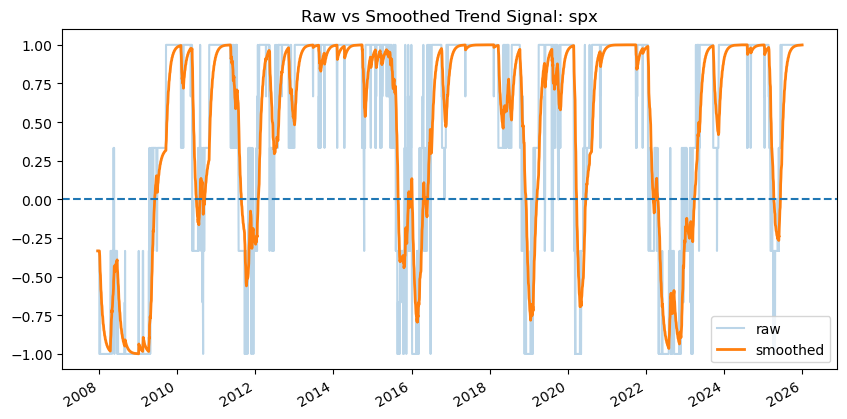

In [ ]:
# check smoothed vs raw
ticker = "spx"

fig, ax = plt.subplots(figsize=(10, 5))

signal_raw[ticker].plot(ax=ax, alpha=0.3, label="raw")
signal[ticker].plot(ax=ax, linewidth=2, label="smoothed")

ax.axhline(0, linestyle="--")
ax.set_title(f"Raw vs Smoothed Trend Signal: {ticker}")
ax.legend()

plt.show()

In [6]:
# sanity checks

summary = summarize_signal(signal, warmup=max(LOOKBACKS) + 1)
print(summary["missing"].head(10))
print(summary["abs_mean"].head(10))
print(summary["abs_mean"].tail(10))
print(summary["describe"])
print("Min/Max:", summary["bounds"])

ticker
hy_credit           0.015304
nikkei              0.000629
spx                 0.000419
rty                 0.000419
ndx                 0.000419
ig_credit           0.000419
ust_intermediate    0.000419
ftse                0.000210
dxy                 0.000210
oil                 0.000210
dtype: float64
ticker
ndx          0.736078
spx          0.733485
gold         0.652193
rty          0.645916
eurusd       0.644324
hy_credit    0.630458
usdjpy       0.623404
nikkei       0.623092
ftse         0.620702
dxy          0.612237
dtype: float64
ticker
hy_credit           0.630458
usdjpy              0.623404
nikkei              0.623092
ftse                0.620702
dxy                 0.612237
ig_credit           0.605272
gbpusd              0.599379
ust_intermediate    0.599258
audusd              0.596481
oil                 0.594255
dtype: float64
count    71461.000000
mean         0.153309
std          0.690946
min         -1.000000
25%         -0.488472
50%          0.259823
75

In [7]:
signal.to_parquet("data/processed/signals_trend.parquet")